# 🧪 Lab 02: Regressão Baseline com Scikit-Learn
**Módulo:** `01-machine-learning / regression-classification`

## Objetivos
1. Compreender o problema de predição de variáveis numéricas contínuas.
2. Treinar modelos de **Regressão Linear**, **Ridge (L2)** e **Árvore de Decisão para Regressão**.
3. Avaliar o desempenho utilizando métricas fundamentais: MAE, MSE, RMSE e $R^2$.
4. Analisar os resíduos do modelo para diagnosticar erros de previsão.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuração gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

## 1. Carregamento e Inspeção dos Dados (California Housing)

In [2]:
# Carrega dataset do Scikit-Learn (amostra de 2000 linhas para execução rápida)
housing = fetch_california_housing(as_frame=True)
df = housing.frame.sample(n=2000, random_state=42)

print("--- Primeiras linhas ---")
display(df.head())

print("\n--- Correlação com o Preço Médio da Casa (MedHouseVal) ---")
correlacoes = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlacoes)

--- Primeiras linhas ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000



--- Correlação com o Preço Médio da Casa (MedHouseVal) ---
MedHouseVal    1.000000
MedInc         0.671899
AveRooms       0.186804
HouseAge       0.106338
Population    -0.033838
Longitude     -0.036323
AveBedrms     -0.051887
AveOccup      -0.109467
Latitude      -0.156292
Name: MedHouseVal, dtype: float64


## 2. Divisão e Padronização

In [3]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Treinamento e Comparação de Modelos

In [4]:
modelos = {
    'Regressão Linear': LinearRegression(),
    'Regressão Ridge': Ridge(alpha=1.0),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=5, random_state=42)
}

resultados = []

for nome, model in modelos.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        'Modelo': nome,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R² Score': round(r2, 4)
    })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,Modelo,MAE,RMSE,R² Score
0,Regressão Linear,0.5319,0.7108,0.6347
1,Regressão Ridge,0.5317,0.7108,0.6347
2,Árvore de Decisão,0.5479,0.7603,0.5820


## 4. Análise de Resíduos (Erros do Modelo)

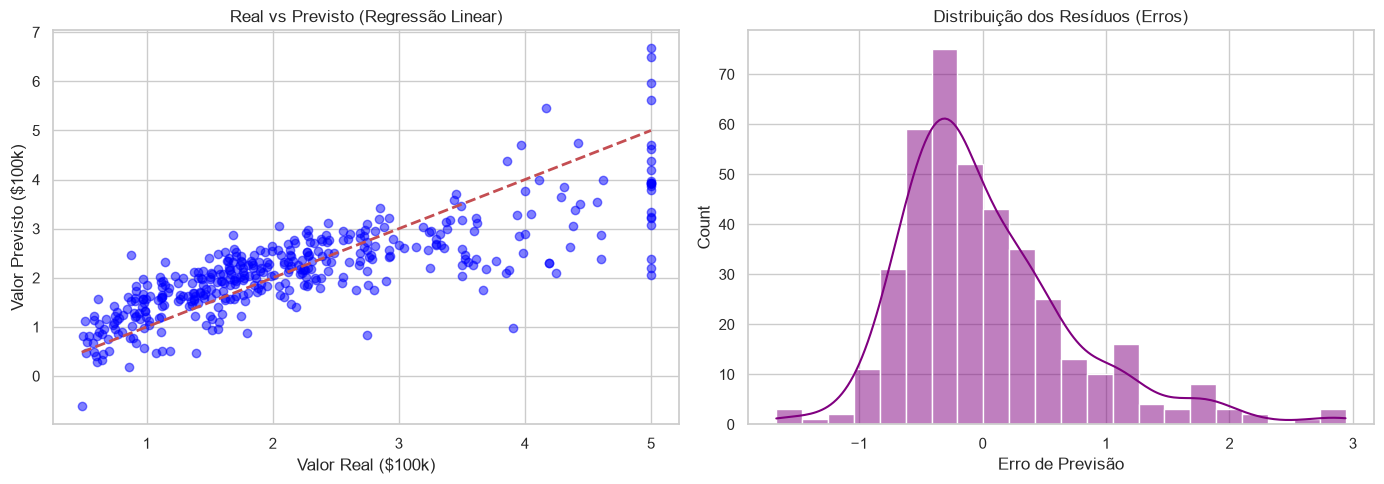

In [5]:
lr_model = modelos['Regressão Linear']
y_pred_lr = lr_model.predict(X_test_scaled)
residuos = y_test - y_pred_lr

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Real vs Previsto
ax[0].scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_xlabel('Valor Real ($100k)')
ax[0].set_ylabel('Valor Previsto ($100k)')
ax[0].set_title('Real vs Previsto (Regressão Linear)')

# Distribuição dos Resíduos
sns.histplot(residuos, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Distribuição dos Resíduos (Erros)')
ax[1].set_xlabel('Erro de Previsão')

plt.tight_layout()
plt.show()